## Detect Depression Severities

### MiniMax-M2.5

In [ ]:
key = " "

import pandas as pd
import json, os, time
from tqdm import *
from openai import OpenAI

def identify_depression(text):
    client = OpenAI(
        base_url="https://api.siliconflow.cn/v1",
        api_key=key
    )
    prompt = f"""The meanings of tweets at each depression level are as follows：
    - **Non-depressed Tweets**: These tweets express joy, make general statements about depression without personal mental state reflection, or convey casual tiredness, sadness, or temporary hopelessness. They may also express any non-depressive emotion.

    - **Mildly depressed Tweets**: These convey persistent hopelessness or disinterest, with symptoms like guilt, concentration issues, loss of interest, social withdrawal, lack of motivation, weight/appetite changes, daytime sleepiness and fatigue, or reckless behavior (such as, alcohol and drug abuse).

    - **Moderately depressed Tweets**: Similar to mild depression but severe enough to disrupt home/work activities. Symptoms include sensitivity, worthlessness, reduced productivity, low self-esteem, and excessive worry.

    - **Severely depressed Tweets**: These are marked by delusions, insensibility, hallucinations, or suicidal thoughts/behaviors, posing significant life threats.

    Based on the above depression level classification, determine the depression level of the tweet with single-choice options: (甲) Non-depressed, (乙) Mildly depressed, (丙) Moderately depressed, (丁) Severely depressed.

    Tweet: "{text}"

    Please directly output the depression level option 甲, 乙, 丙, or 丁."""

    response = client.chat.completions.create(
        model="Pro/MiniMaxAI/MiniMax-M2.5",
        messages=[
            {"role": "user", "content": prompt},
        ],
        max_tokens=2000,
        n=1,
        stop=None,
        temperature=0.5,
    )
    return response.choices[0].message.content

# 确保输出目录存在
output_json_path = "/data/zhengtianlong/Private/Depressed/Close_LLM_Deptweet/MiniMax-M2.5_Depression.json"
os.makedirs(os.path.dirname(output_json_path), exist_ok=True)

# 如果输出文件已存在，加载已有的ID集合
success_ids = set()
if os.path.exists(output_json_path):
    try:
        with open(output_json_path, "r") as json_file:
            existing_data = json.load(json_file)
            success_ids = {item["Id"] for item in existing_data}
    except json.JSONDecodeError:
        # 文件为空或损坏，重新初始化
        with open(output_json_path, "w") as json_file:
            json.dump([], json_file)
else:
    with open(output_json_path, "w") as json_file:
        json.dump([], json_file)

# 读取数据
data = pd.read_csv('/data/zhengtianlong/Private/Depressed/Deptweet/Deptweet_test.csv')
# 不打乱数据（已移除shuffle）

# 获取所有样本ID（转换为字符串以便比较）
all_ids = set(data['id'].astype(str).tolist())

max_retries = 5
current_retry = 0

# 循环直到所有样本成功或达到最大重试次数
while current_retry < max_retries and len(success_ids) < len(all_ids):
    current_retry += 1
    remaining = len(all_ids) - len(success_ids)
    print(f"重试第 {current_retry}/{max_retries} 轮，剩余 {remaining} 条样本")

    # 本轮需要处理的样本：ID不在 success_ids 中的
    remaining_data = data[~data['id'].astype(str).isin(success_ids)]

    if remaining_data.empty:
        print("所有样本已处理完成")
        break

    # 遍历剩余样本
    for _, row in tqdm(remaining_data.iterrows(), desc=f"第{current_retry}轮", total=len(remaining_data)):
        try:
            Id = str(row['id'])
            text = row['text']
            target = row['target']
            label = row['label']

            if pd.isna(text) or pd.isna(label):
                print(f"跳过缺失文本或标签的样本: {Id}")
                continue

            # 二次检查（理论上不在success_ids中）
            if Id in success_ids:
                continue

            target = str(int(target))  # 保持原处理

            # 调用API
            predict = identify_depression(text)

            result = {"Id": Id, "text": text, "predict": predict, "label": target, "target": label}

            # 写入文件（实时保存）
            with open(output_json_path, "r+") as json_file:
                file_data = json.load(json_file)
                existing_ids = {item["Id"] for item in file_data}
                if Id not in existing_ids:
                    file_data.append(result)
                    json_file.seek(0)
                    json.dump(file_data, json_file, ensure_ascii=False, indent=4)
                    json_file.truncate()  # 清除多余内容
                    success_ids.add(Id)
                else:
                    # 极少情况：文件中有但success_ids没有，则同步
                    print(f"警告: Id {Id} 已存在于文件但不在成功集合中，标记为成功")
                    success_ids.add(Id)

            time.sleep(0.5)  # 保持原延迟

        except Exception as e:
            print(f"处理样本 {Id if 'Id' in locals() else 'unknown'} 时出错: {e}")
            # 失败的不写入，留待下一轮重试
            continue

# ========== 确保最终JSON顺序与原始CSV行顺序一致 ==========
print("正在按原始CSV顺序重新排序输出文件...")
# 构建ID到原始行顺序的映射
id_to_order = {str(row['id']): idx for idx, row in data.iterrows()}

# 读取当前输出文件
with open(output_json_path, "r") as f:
    final_data = json.load(f)

# 按原始顺序排序（缺失的ID放在最后，但理论上不会出现）
final_data.sort(key=lambda x: id_to_order.get(x['Id'], float('inf')))

# 写回文件
with open(output_json_path, "w") as f:
    json.dump(final_data, f, ensure_ascii=False, indent=4)

print("排序完成！")

# 最终结果统计
if len(success_ids) == len(all_ids):
    print("所有样本处理成功！")
else:
    print(f"经过 {max_retries} 轮重试后，仍有 {len(all_ids) - len(success_ids)} 条样本未成功。")

正在按原始CSV顺序重新排序输出文件...
排序完成！
所有样本处理成功！


In [2]:
import json, random
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 读取JSON文件
input_file_path = '/data/zhengtianlong/Private/Depressed/Close_LLM_Deptweet/MiniMax-M2.5_Depression.json'
data = []

with open(input_file_path, 'r', encoding='utf-8') as file:
    data = json.load(file)

# 提取预测值和真实标签
def map_label(predict):
    if "甲" in predict:
        return 0
    elif "乙" in predict:
        return 1
    elif "丙" in predict:
        return 2
    elif "丁" in predict:
        return 3
    else:
        return 3 
        # 为什么要返回3而不是其他 答：模型选择不回答，有可能是因为抑郁症过于严重导致语言过于激烈导致模型无法回答
        # return random.choice([0, 1, 2, 3])

y_true = [int(item["label"]) for item in data]
y_pred = [map_label(item["predict"]) for item in data]

# 计算指标
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')


Accuracy: 81.39%
Precision: 53.82%
Recall: 59.89%
F1 Score: 53.36%


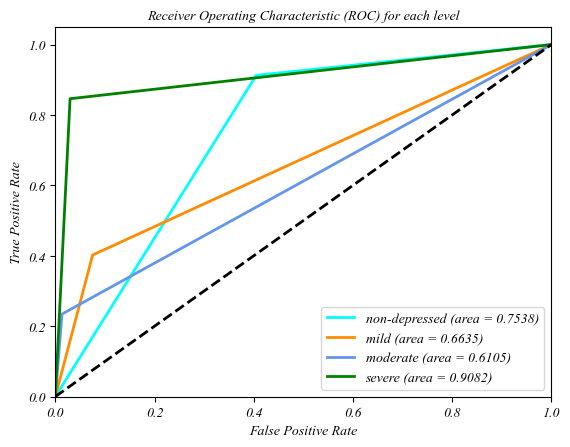

In [1]:
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 加载 Times New Roman 字体
font_path = '/data/zhengtianlong/ttf/timesi.ttf'
times_new_roman_font = fm.FontProperties(fname=font_path)

# 读取JSON文件
input_file_path = '/data/zhengtianlong/Private/Depressed/Close_LLM_Deptweet/MiniMax-M2.5_Depression.json'

with open(input_file_path, 'r', encoding='utf-8') as file:
    data = json.load(file)

# 提取预测值和真实标签
def map_label(predict):
    if "甲" in predict:
        return 0
    elif "乙" in predict:
        return 1
    elif "丙" in predict:
        return 2
    elif "丁" in predict:
        return 3
    else:
        return 3

y_true = [int(item["label"]) for item in data]
y_pred = [map_label(item["predict"]) for item in data]

# 将标签二值化
n_classes = 4
y_true_binarized = label_binarize(y_true, classes=[0, 1, 2, 3])
y_pred_binarized = label_binarize(y_pred, classes=[0, 1, 2, 3])
# 类名映射
class_names = {0: "non-depressed", 1: "mild", 2: "moderate", 3: "severe"}
# 计算ROC曲线和AUC
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_binarized[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 绘制所有类别的ROC曲线
plt.figure()
colors = ['aqua', 'darkorange', 'cornflowerblue', 'green']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             lw=2, label=f'{class_names[i]} (area = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontproperties=times_new_roman_font)
plt.ylabel('True Positive Rate', fontproperties=times_new_roman_font)
plt.title('Receiver Operating Characteristic (ROC) for each level', fontproperties=times_new_roman_font)
plt.legend(loc="lower right", prop=times_new_roman_font)

# 设置刻度字体
plt.xticks(fontproperties=times_new_roman_font)
plt.yticks(fontproperties=times_new_roman_font)

plt.savefig('/data/zhengtianlong/Private/Depressed/result_IMG/MiniMax-M2.5_curves.png', format='png', dpi=800, bbox_inches='tight')
plt.show()


### MiniMax-M2.7

In [ ]:
key = " "

import pandas as pd
import json, os, time
from tqdm import *
from openai import OpenAI

def identify_depression(text):
    client = OpenAI(
        base_url="https://api.linkapi.org/v1",
        api_key=key
    )
    prompt = f"""The meanings of tweets at each depression level are as follows：
    - **Non-depressed Tweets**: These tweets express joy, make general statements about depression without personal mental state reflection, or convey casual tiredness, sadness, or temporary hopelessness. They may also express any non-depressive emotion.

    - **Mildly depressed Tweets**: These convey persistent hopelessness or disinterest, with symptoms like guilt, concentration issues, loss of interest, social withdrawal, lack of motivation, weight/appetite changes, daytime sleepiness and fatigue, or reckless behavior (such as, alcohol and drug abuse).

    - **Moderately depressed Tweets**: Similar to mild depression but severe enough to disrupt home/work activities. Symptoms include sensitivity, worthlessness, reduced productivity, low self-esteem, and excessive worry.

    - **Severely depressed Tweets**: These are marked by delusions, insensibility, hallucinations, or suicidal thoughts/behaviors, posing significant life threats.

    Based on the above depression level classification, determine the depression level of the tweet with single-choice options: (甲) Non-depressed, (乙) Mildly depressed, (丙) Moderately depressed, (丁) Severely depressed.

    Tweet: "{text}"

    Please directly output the depression level option 甲, 乙, 丙, or 丁."""

    response = client.chat.completions.create(
        model="MiniMax-M2.7",
        messages=[
            {"role": "user", "content": prompt},
        ],
        max_tokens=4000,
        n=1,
        stop=None,
        temperature=0.5,
    )
    return response.choices[0].message.content

# 确保输出目录存在
output_json_path = "/data/zhengtianlong/Private/Depressed/Close_LLM_Deptweet/MiniMax-M2.7_Depression.json"
os.makedirs(os.path.dirname(output_json_path), exist_ok=True)

# 如果输出文件已存在，加载已有的ID集合
success_ids = set()
if os.path.exists(output_json_path):
    try:
        with open(output_json_path, "r") as json_file:
            existing_data = json.load(json_file)
            success_ids = {item["Id"] for item in existing_data}
    except json.JSONDecodeError:
        # 文件为空或损坏，重新初始化
        with open(output_json_path, "w") as json_file:
            json.dump([], json_file)
else:
    with open(output_json_path, "w") as json_file:
        json.dump([], json_file)

# 读取数据
data = pd.read_csv('/data/zhengtianlong/Private/Depressed/Deptweet/Deptweet_test.csv')
# 不打乱数据（已移除shuffle）

# 获取所有样本ID（转换为字符串以便比较）
all_ids = set(data['id'].astype(str).tolist())

max_retries = 5
current_retry = 0

# 循环直到所有样本成功或达到最大重试次数
while current_retry < max_retries and len(success_ids) < len(all_ids):
    current_retry += 1
    remaining = len(all_ids) - len(success_ids)
    print(f"重试第 {current_retry}/{max_retries} 轮，剩余 {remaining} 条样本")

    # 本轮需要处理的样本：ID不在 success_ids 中的
    remaining_data = data[~data['id'].astype(str).isin(success_ids)]

    if remaining_data.empty:
        print("所有样本已处理完成")
        break

    # 遍历剩余样本
    for _, row in tqdm(remaining_data.iterrows(), desc=f"第{current_retry}轮", total=len(remaining_data)):
        try:
            Id = str(row['id'])
            text = row['text']
            target = row['target']
            label = row['label']

            if pd.isna(text) or pd.isna(label):
                print(f"跳过缺失文本或标签的样本: {Id}")
                continue

            # 二次检查（理论上不在success_ids中）
            if Id in success_ids:
                continue

            target = str(int(target))  # 保持原处理

            # 调用API
            predict = identify_depression(text)

            result = {"Id": Id, "text": text, "predict": predict, "label": target, "target": label}

            # 写入文件（实时保存）
            with open(output_json_path, "r+") as json_file:
                file_data = json.load(json_file)
                existing_ids = {item["Id"] for item in file_data}
                if Id not in existing_ids:
                    file_data.append(result)
                    json_file.seek(0)
                    json.dump(file_data, json_file, ensure_ascii=False, indent=4)
                    json_file.truncate()  # 清除多余内容
                    success_ids.add(Id)
                else:
                    # 极少情况：文件中有但success_ids没有，则同步
                    print(f"警告: Id {Id} 已存在于文件但不在成功集合中，标记为成功")
                    success_ids.add(Id)

            time.sleep(5)  # 保持原延迟

        except Exception as e:
            print(f"处理样本 {Id if 'Id' in locals() else 'unknown'} 时出错: {e}")
            # 失败的不写入，留待下一轮重试
            continue

# ========== 确保最终JSON顺序与原始CSV行顺序一致 ==========
print("正在按原始CSV顺序重新排序输出文件...")
# 构建ID到原始行顺序的映射
id_to_order = {str(row['id']): idx for idx, row in data.iterrows()}

# 读取当前输出文件
with open(output_json_path, "r") as f:
    final_data = json.load(f)

# 按原始顺序排序（缺失的ID放在最后，但理论上不会出现）
final_data.sort(key=lambda x: id_to_order.get(x['Id'], float('inf')))

# 写回文件
with open(output_json_path, "w") as f:
    json.dump(final_data, f, ensure_ascii=False, indent=4)

print("排序完成！")

# 最终结果统计
if len(success_ids) == len(all_ids):
    print("所有样本处理成功！")
else:
    print(f"经过 {max_retries} 轮重试后，仍有 {len(all_ids) - len(success_ids)} 条样本未成功。")

重试第 1/5 轮，剩余 3 条样本


第1轮:   0%|          | 0/3 [00:00<?, ?it/s]

第1轮: 100%|██████████| 3/3 [01:40<00:00, 33.52s/it]

正在按原始CSV顺序重新排序输出文件...
排序完成！
所有样本处理成功！


In [8]:
import json, random
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 读取JSON文件
input_file_path = '/data/zhengtianlong/Private/Depressed/Close_LLM_Deptweet/MiniMax-M2.7_Depression.json'
data = []

with open(input_file_path, 'r', encoding='utf-8') as file:
    data = json.load(file)

# 提取预测值和真实标签
def map_label(predict):
    if "甲" in predict:
        return 0
    elif "乙" in predict:
        return 1
    elif "丙" in predict:
        return 2
    elif "丁" in predict:
        return 3
    else:
        return 3 
        # 为什么要返回3而不是其他 答：模型选择不回答，有可能是因为抑郁症过于严重导致语言过于激烈导致模型无法回答
        # return random.choice([0, 1, 2, 3])

y_true = [int(item["label"]) for item in data]
y_pred = [map_label(item["predict"]) for item in data]

# 计算指标
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')


Accuracy: 80.26%
Precision: 50.35%
Recall: 60.27%
F1 Score: 52.05%


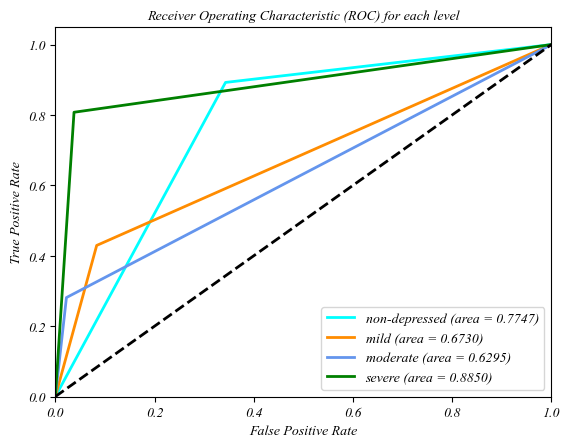

In [9]:
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 加载 Times New Roman 字体
font_path = '/data/zhengtianlong/ttf/timesi.ttf'
times_new_roman_font = fm.FontProperties(fname=font_path)

# 读取JSON文件
input_file_path = '/data/zhengtianlong/Private/Depressed/Close_LLM_Deptweet/MiniMax-M2.7_Depression.json'

with open(input_file_path, 'r', encoding='utf-8') as file:
    data = json.load(file)

# 提取预测值和真实标签
def map_label(predict):
    if "甲" in predict:
        return 0
    elif "乙" in predict:
        return 1
    elif "丙" in predict:
        return 2
    elif "丁" in predict:
        return 3
    else:
        return 3

y_true = [int(item["label"]) for item in data]
y_pred = [map_label(item["predict"]) for item in data]

# 将标签二值化
n_classes = 4
y_true_binarized = label_binarize(y_true, classes=[0, 1, 2, 3])
y_pred_binarized = label_binarize(y_pred, classes=[0, 1, 2, 3])
# 类名映射
class_names = {0: "non-depressed", 1: "mild", 2: "moderate", 3: "severe"}
# 计算ROC曲线和AUC
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_binarized[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 绘制所有类别的ROC曲线
plt.figure()
colors = ['aqua', 'darkorange', 'cornflowerblue', 'green']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             lw=2, label=f'{class_names[i]} (area = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontproperties=times_new_roman_font)
plt.ylabel('True Positive Rate', fontproperties=times_new_roman_font)
plt.title('Receiver Operating Characteristic (ROC) for each level', fontproperties=times_new_roman_font)
plt.legend(loc="lower right", prop=times_new_roman_font)

# 设置刻度字体
plt.xticks(fontproperties=times_new_roman_font)
plt.yticks(fontproperties=times_new_roman_font)

plt.savefig('/data/zhengtianlong/Private/Depressed/result_IMG/MiniMax-M2.7_curves.png', format='png', dpi=800, bbox_inches='tight')
plt.show()


### Pro/zai-org/GLM-5

In [ ]:
key = " "

import pandas as pd
import json, os, time
from tqdm import *
from openai import OpenAI

def identify_depression(text):
    client = OpenAI(
        base_url="https://api.siliconflow.cn/v1",
        api_key=key
    )
    prompt = f"""The meanings of tweets at each depression level are as follows：
    - **Non-depressed Tweets**: These tweets express joy, make general statements about depression without personal mental state reflection, or convey casual tiredness, sadness, or temporary hopelessness. They may also express any non-depressive emotion.

    - **Mildly depressed Tweets**: These convey persistent hopelessness or disinterest, with symptoms like guilt, concentration issues, loss of interest, social withdrawal, lack of motivation, weight/appetite changes, daytime sleepiness and fatigue, or reckless behavior (such as, alcohol and drug abuse).

    - **Moderately depressed Tweets**: Similar to mild depression but severe enough to disrupt home/work activities. Symptoms include sensitivity, worthlessness, reduced productivity, low self-esteem, and excessive worry.

    - **Severely depressed Tweets**: These are marked by delusions, insensibility, hallucinations, or suicidal thoughts/behaviors, posing significant life threats.

    Based on the above depression level classification, determine the depression level of the tweet with single-choice options: (甲) Non-depressed, (乙) Mildly depressed, (丙) Moderately depressed, (丁) Severely depressed.

    Tweet: "{text}"

    Please directly output the depression level option 甲, 乙, 丙, or 丁."""

    response = client.chat.completions.create(
        model="Pro/zai-org/GLM-5",
        messages=[
            {"role": "user", "content": prompt},
        ],
        max_tokens=2000,
        n=1,
        stop=None,
        temperature=0.5,
    )
    return response.choices[0].message.content

# 确保输出目录存在
output_json_path = "/data/zhengtianlong/Private/Depressed/Close_LLM_Deptweet/GLM-5_Depression.json"
os.makedirs(os.path.dirname(output_json_path), exist_ok=True)

# 如果输出文件已存在，加载已有的ID集合
success_ids = set()
if os.path.exists(output_json_path):
    try:
        with open(output_json_path, "r") as json_file:
            existing_data = json.load(json_file)
            success_ids = {item["Id"] for item in existing_data}
    except json.JSONDecodeError:
        # 文件为空或损坏，重新初始化
        with open(output_json_path, "w") as json_file:
            json.dump([], json_file)
else:
    with open(output_json_path, "w") as json_file:
        json.dump([], json_file)

# 读取数据
data = pd.read_csv('/data/zhengtianlong/Private/Depressed/Deptweet/Deptweet_test.csv')
# 不打乱数据（已移除shuffle）

# 获取所有样本ID（转换为字符串以便比较）
all_ids = set(data['id'].astype(str).tolist())

max_retries = 5
current_retry = 0

# 循环直到所有样本成功或达到最大重试次数
while current_retry < max_retries and len(success_ids) < len(all_ids):
    current_retry += 1
    remaining = len(all_ids) - len(success_ids)
    print(f"重试第 {current_retry}/{max_retries} 轮，剩余 {remaining} 条样本")

    # 本轮需要处理的样本：ID不在 success_ids 中的
    remaining_data = data[~data['id'].astype(str).isin(success_ids)]

    if remaining_data.empty:
        print("所有样本已处理完成")
        break

    # 遍历剩余样本
    for _, row in tqdm(remaining_data.iterrows(), desc=f"第{current_retry}轮", total=len(remaining_data)):
        try:
            Id = str(row['id'])
            text = row['text']
            target = row['target']
            label = row['label']

            if pd.isna(text) or pd.isna(label):
                print(f"跳过缺失文本或标签的样本: {Id}")
                continue

            # 二次检查（理论上不在success_ids中）
            if Id in success_ids:
                continue

            target = str(int(target))  # 保持原处理

            # 调用API
            predict = identify_depression(text)

            result = {"Id": Id, "text": text, "predict": predict, "label": target, "target": label}

            # 写入文件（实时保存）
            with open(output_json_path, "r+") as json_file:
                file_data = json.load(json_file)
                existing_ids = {item["Id"] for item in file_data}
                if Id not in existing_ids:
                    file_data.append(result)
                    json_file.seek(0)
                    json.dump(file_data, json_file, ensure_ascii=False, indent=4)
                    json_file.truncate()  # 清除多余内容
                    success_ids.add(Id)
                else:
                    # 极少情况：文件中有但success_ids没有，则同步
                    print(f"警告: Id {Id} 已存在于文件但不在成功集合中，标记为成功")
                    success_ids.add(Id)

            time.sleep(0.5)  # 保持原延迟

        except Exception as e:
            print(f"处理样本 {Id if 'Id' in locals() else 'unknown'} 时出错: {e}")
            # 失败的不写入，留待下一轮重试
            continue

# ========== 确保最终JSON顺序与原始CSV行顺序一致 ==========
print("正在按原始CSV顺序重新排序输出文件...")
# 构建ID到原始行顺序的映射
id_to_order = {str(row['id']): idx for idx, row in data.iterrows()}

# 读取当前输出文件
with open(output_json_path, "r") as f:
    final_data = json.load(f)

# 按原始顺序排序（缺失的ID放在最后，但理论上不会出现）
final_data.sort(key=lambda x: id_to_order.get(x['Id'], float('inf')))

# 写回文件
with open(output_json_path, "w") as f:
    json.dump(final_data, f, ensure_ascii=False, indent=4)

print("排序完成！")

# 最终结果统计
if len(success_ids) == len(all_ids):
    print("所有样本处理成功！")
else:
    print(f"经过 {max_retries} 轮重试后，仍有 {len(all_ids) - len(success_ids)} 条样本未成功。")

重试第 1/5 轮，剩余 232 条样本


第1轮:   0%|          | 0/232 [00:00<?, ?it/s]

第1轮: 100%|██████████| 232/232 [4:12:59<00:00, 65.43s/it]    

正在按原始CSV顺序重新排序输出文件...
排序完成！
所有样本处理成功！


In [5]:
import json, random
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 读取JSON文件
input_file_path = '/data/zhengtianlong/Private/Depressed/Close_LLM_Deptweet/GLM-5_Depression.json'
data = []

with open(input_file_path, 'r', encoding='utf-8') as file:
    data = json.load(file)

# 提取预测值和真实标签
def map_label(predict):
    if "甲" in predict:
        return 0
    elif "乙" in predict:
        return 1
    elif "丙" in predict:
        return 2
    elif "丁" in predict:
        return 3
    else:
        return 3 
        # 为什么要返回3而不是其他 答：模型选择不回答，有可能是因为抑郁症过于严重导致语言过于激烈导致模型无法回答
        # return random.choice([0, 1, 2, 3])

y_true = [int(item["label"]) for item in data]
y_pred = [map_label(item["predict"]) for item in data]

# 计算指标
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')


Accuracy: 82.46%
Precision: 54.94%
Recall: 63.82%
F1 Score: 57.59%


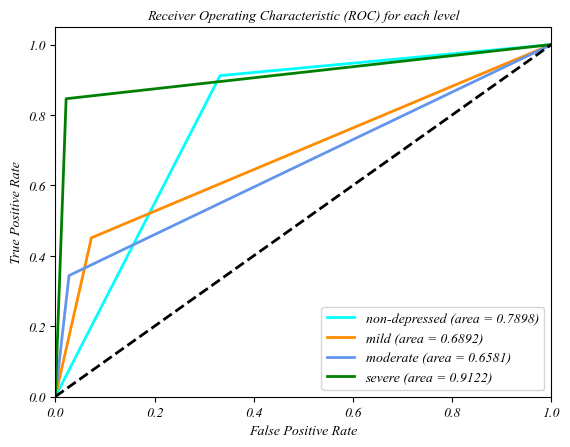

In [6]:
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 加载 Times New Roman 字体
font_path = '/data/zhengtianlong/ttf/timesi.ttf'
times_new_roman_font = fm.FontProperties(fname=font_path)

# 读取JSON文件
input_file_path = '/data/zhengtianlong/Private/Depressed/Close_LLM_Deptweet/GLM-5_Depression.json'

with open(input_file_path, 'r', encoding='utf-8') as file:
    data = json.load(file)

# 提取预测值和真实标签
def map_label(predict):
    if "甲" in predict:
        return 0
    elif "乙" in predict:
        return 1
    elif "丙" in predict:
        return 2
    elif "丁" in predict:
        return 3
    else:
        return 3

y_true = [int(item["label"]) for item in data]
y_pred = [map_label(item["predict"]) for item in data]

# 将标签二值化
n_classes = 4
y_true_binarized = label_binarize(y_true, classes=[0, 1, 2, 3])
y_pred_binarized = label_binarize(y_pred, classes=[0, 1, 2, 3])
# 类名映射
class_names = {0: "non-depressed", 1: "mild", 2: "moderate", 3: "severe"}
# 计算ROC曲线和AUC
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_binarized[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 绘制所有类别的ROC曲线
plt.figure()
colors = ['aqua', 'darkorange', 'cornflowerblue', 'green']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             lw=2, label=f'{class_names[i]} (area = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontproperties=times_new_roman_font)
plt.ylabel('True Positive Rate', fontproperties=times_new_roman_font)
plt.title('Receiver Operating Characteristic (ROC) for each level', fontproperties=times_new_roman_font)
plt.legend(loc="lower right", prop=times_new_roman_font)

# 设置刻度字体
plt.xticks(fontproperties=times_new_roman_font)
plt.yticks(fontproperties=times_new_roman_font)

plt.savefig('/data/zhengtianlong/Private/Depressed/result_IMG/GLM-5_curves.png', format='png', dpi=800, bbox_inches='tight')
plt.show()


### stepfun-ai/Step-3.5-Flash

In [ ]:
key = " "

import pandas as pd
import json, os, time
from tqdm import *
from openai import OpenAI

def identify_depression(text):
    client = OpenAI(
        base_url="https://api.siliconflow.cn/v1",
        api_key=key
    )
    prompt = f"""The meanings of tweets at each depression level are as follows：
    - **Non-depressed Tweets**: These tweets express joy, make general statements about depression without personal mental state reflection, or convey casual tiredness, sadness, or temporary hopelessness. They may also express any non-depressive emotion.

    - **Mildly depressed Tweets**: These convey persistent hopelessness or disinterest, with symptoms like guilt, concentration issues, loss of interest, social withdrawal, lack of motivation, weight/appetite changes, daytime sleepiness and fatigue, or reckless behavior (such as, alcohol and drug abuse).

    - **Moderately depressed Tweets**: Similar to mild depression but severe enough to disrupt home/work activities. Symptoms include sensitivity, worthlessness, reduced productivity, low self-esteem, and excessive worry.

    - **Severely depressed Tweets**: These are marked by delusions, insensibility, hallucinations, or suicidal thoughts/behaviors, posing significant life threats.

    Based on the above depression level classification, determine the depression level of the tweet with single-choice options: (甲) Non-depressed, (乙) Mildly depressed, (丙) Moderately depressed, (丁) Severely depressed.

    Tweet: "{text}"

    Please directly output the depression level option 甲, 乙, 丙, or 丁."""

    response = client.chat.completions.create(
        model="stepfun-ai/Step-3.5-Flash",
        messages=[
            {"role": "user", "content": prompt},
        ],
        max_tokens=4000,
        n=1,
        stop=None,
        temperature=0.5,
    )
    return response.choices[0].message.content

# 确保输出目录存在
output_json_path = "/data/zhengtianlong/Private/Depressed/Close_LLM_Deptweet/Step-3.5-Flash_Depression.json"
os.makedirs(os.path.dirname(output_json_path), exist_ok=True)

# 如果输出文件已存在，加载已有的ID集合
success_ids = set()
if os.path.exists(output_json_path):
    try:
        with open(output_json_path, "r") as json_file:
            existing_data = json.load(json_file)
            success_ids = {item["Id"] for item in existing_data}
    except json.JSONDecodeError:
        # 文件为空或损坏，重新初始化
        with open(output_json_path, "w") as json_file:
            json.dump([], json_file)
else:
    with open(output_json_path, "w") as json_file:
        json.dump([], json_file)

# 读取数据
data = pd.read_csv('/data/zhengtianlong/Private/Depressed/Deptweet/Deptweet_test.csv')
# 不打乱数据（已移除shuffle）

# 获取所有样本ID（转换为字符串以便比较）
all_ids = set(data['id'].astype(str).tolist())

max_retries = 5
current_retry = 0

# 循环直到所有样本成功或达到最大重试次数
while current_retry < max_retries and len(success_ids) < len(all_ids):
    current_retry += 1
    remaining = len(all_ids) - len(success_ids)
    print(f"重试第 {current_retry}/{max_retries} 轮，剩余 {remaining} 条样本")

    # 本轮需要处理的样本：ID不在 success_ids 中的
    remaining_data = data[~data['id'].astype(str).isin(success_ids)]

    if remaining_data.empty:
        print("所有样本已处理完成")
        break

    # 遍历剩余样本
    for _, row in tqdm(remaining_data.iterrows(), desc=f"第{current_retry}轮", total=len(remaining_data)):
        try:
            Id = str(row['id'])
            text = row['text']
            target = row['target']
            label = row['label']

            if pd.isna(text) or pd.isna(label):
                print(f"跳过缺失文本或标签的样本: {Id}")
                continue

            # 二次检查（理论上不在success_ids中）
            if Id in success_ids:
                continue

            target = str(int(target))  # 保持原处理

            # 调用API
            predict = identify_depression(text)

            result = {"Id": Id, "text": text, "predict": predict, "label": target, "target": label}

            # 写入文件（实时保存）
            with open(output_json_path, "r+") as json_file:
                file_data = json.load(json_file)
                existing_ids = {item["Id"] for item in file_data}
                if Id not in existing_ids:
                    file_data.append(result)
                    json_file.seek(0)
                    json.dump(file_data, json_file, ensure_ascii=False, indent=4)
                    json_file.truncate()  # 清除多余内容
                    success_ids.add(Id)
                else:
                    # 极少情况：文件中有但success_ids没有，则同步
                    print(f"警告: Id {Id} 已存在于文件但不在成功集合中，标记为成功")
                    success_ids.add(Id)

            time.sleep(0.5)  # 保持原延迟

        except Exception as e:
            print(f"处理样本 {Id if 'Id' in locals() else 'unknown'} 时出错: {e}")
            # 失败的不写入，留待下一轮重试
            continue

# ========== 确保最终JSON顺序与原始CSV行顺序一致 ==========
print("正在按原始CSV顺序重新排序输出文件...")
# 构建ID到原始行顺序的映射
id_to_order = {str(row['id']): idx for idx, row in data.iterrows()}

# 读取当前输出文件
with open(output_json_path, "r") as f:
    final_data = json.load(f)

# 按原始顺序排序（缺失的ID放在最后，但理论上不会出现）
final_data.sort(key=lambda x: id_to_order.get(x['Id'], float('inf')))

# 写回文件
with open(output_json_path, "w") as f:
    json.dump(final_data, f, ensure_ascii=False, indent=4)

print("排序完成！")

# 最终结果统计
if len(success_ids) == len(all_ids):
    print("所有样本处理成功！")
else:
    print(f"经过 {max_retries} 轮重试后，仍有 {len(all_ids) - len(success_ids)} 条样本未成功。")

重试第 1/5 轮，剩余 2 条样本


第1轮: 100%|██████████| 2/2 [00:16<00:00,  8.38s/it]

正在按原始CSV顺序重新排序输出文件...
排序完成！
所有样本处理成功！


In [7]:
import json, random
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 读取JSON文件
input_file_path = '/data/zhengtianlong/Private/Depressed/Close_LLM_Deptweet/Step-3.5-Flash_Depression.json'
data = []

with open(input_file_path, 'r', encoding='utf-8') as file:
    data = json.load(file)

# 提取预测值和真实标签
def map_label(predict):
    if "甲" in predict:
        return 0
    elif "乙" in predict:
        return 1
    elif "丙" in predict:
        return 2
    elif "丁" in predict:
        return 3
    else:
        return 3 
        # 为什么要返回3而不是其他 答：模型选择不回答，有可能是因为抑郁症过于严重导致语言过于激烈导致模型无法回答
        # return random.choice([0, 1, 2, 3])

y_true = [int(item["label"]) for item in data]
y_pred = [map_label(item["predict"]) for item in data]

# 计算指标
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')


Accuracy: 79.55%
Precision: 52.04%
Recall: 65.93%
F1 Score: 55.95%


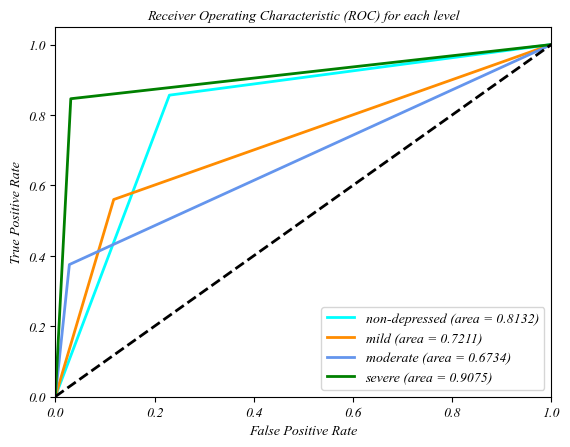

In [8]:
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 加载 Times New Roman 字体
font_path = '/data/zhengtianlong/ttf/timesi.ttf'
times_new_roman_font = fm.FontProperties(fname=font_path)

# 读取JSON文件
input_file_path = '/data/zhengtianlong/Private/Depressed/Close_LLM_Deptweet/Step-3.5-Flash_Depression.json'

with open(input_file_path, 'r', encoding='utf-8') as file:
    data = json.load(file)

# 提取预测值和真实标签
def map_label(predict):
    if "甲" in predict:
        return 0
    elif "乙" in predict:
        return 1
    elif "丙" in predict:
        return 2
    elif "丁" in predict:
        return 3
    else:
        return 3

y_true = [int(item["label"]) for item in data]
y_pred = [map_label(item["predict"]) for item in data]

# 将标签二值化
n_classes = 4
y_true_binarized = label_binarize(y_true, classes=[0, 1, 2, 3])
y_pred_binarized = label_binarize(y_pred, classes=[0, 1, 2, 3])
# 类名映射
class_names = {0: "non-depressed", 1: "mild", 2: "moderate", 3: "severe"}
# 计算ROC曲线和AUC
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_binarized[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 绘制所有类别的ROC曲线
plt.figure()
colors = ['aqua', 'darkorange', 'cornflowerblue', 'green']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             lw=2, label=f'{class_names[i]} (area = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontproperties=times_new_roman_font)
plt.ylabel('True Positive Rate', fontproperties=times_new_roman_font)
plt.title('Receiver Operating Characteristic (ROC) for each level', fontproperties=times_new_roman_font)
plt.legend(loc="lower right", prop=times_new_roman_font)

# 设置刻度字体
plt.xticks(fontproperties=times_new_roman_font)
plt.yticks(fontproperties=times_new_roman_font)

plt.savefig('/data/zhengtianlong/Private/Depressed/result_IMG/Step-3.5-Flash_curves.png', format='png', dpi=800, bbox_inches='tight')
plt.show()


### baidu/ERNIE-4.5-300B-A47B

In [ ]:
key = " "

import pandas as pd
import json, os, time
from tqdm import *
from openai import OpenAI

def identify_depression(text):
    client = OpenAI(
        base_url="https://api.siliconflow.cn/v1",
        api_key=key
    )
    prompt = f"""The meanings of tweets at each depression level are as follows：
    - **Non-depressed Tweets**: These tweets express joy, make general statements about depression without personal mental state reflection, or convey casual tiredness, sadness, or temporary hopelessness. They may also express any non-depressive emotion.

    - **Mildly depressed Tweets**: These convey persistent hopelessness or disinterest, with symptoms like guilt, concentration issues, loss of interest, social withdrawal, lack of motivation, weight/appetite changes, daytime sleepiness and fatigue, or reckless behavior (such as, alcohol and drug abuse).

    - **Moderately depressed Tweets**: Similar to mild depression but severe enough to disrupt home/work activities. Symptoms include sensitivity, worthlessness, reduced productivity, low self-esteem, and excessive worry.

    - **Severely depressed Tweets**: These are marked by delusions, insensibility, hallucinations, or suicidal thoughts/behaviors, posing significant life threats.

    Based on the above depression level classification, determine the depression level of the tweet with single-choice options: (甲) Non-depressed, (乙) Mildly depressed, (丙) Moderately depressed, (丁) Severely depressed.

    Tweet: "{text}"

    Please directly output the depression level option 甲, 乙, 丙, or 丁."""

    response = client.chat.completions.create(
        model="baidu/ERNIE-4.5-300B-A47B",
        messages=[
            {"role": "user", "content": prompt},
        ],
        max_tokens=2000,
        n=1,
        stop=None,
        temperature=0.5,
    )
    return response.choices[0].message.content

# 确保输出目录存在
output_json_path = "/data/zhengtianlong/Private/Depressed/Close_LLM_Deptweet/ERNIE-4.5-300B-A47B_Depression.json"
os.makedirs(os.path.dirname(output_json_path), exist_ok=True)

# 如果输出文件已存在，加载已有的ID集合
success_ids = set()
if os.path.exists(output_json_path):
    try:
        with open(output_json_path, "r") as json_file:
            existing_data = json.load(json_file)
            success_ids = {item["Id"] for item in existing_data}
    except json.JSONDecodeError:
        # 文件为空或损坏，重新初始化
        with open(output_json_path, "w") as json_file:
            json.dump([], json_file)
else:
    with open(output_json_path, "w") as json_file:
        json.dump([], json_file)

# 读取数据
data = pd.read_csv('/data/zhengtianlong/Private/Depressed/Deptweet/Deptweet_test.csv')
# 不打乱数据（已移除shuffle）

# 获取所有样本ID（转换为字符串以便比较）
all_ids = set(data['id'].astype(str).tolist())

max_retries = 5
current_retry = 0

# 循环直到所有样本成功或达到最大重试次数
while current_retry < max_retries and len(success_ids) < len(all_ids):
    current_retry += 1
    remaining = len(all_ids) - len(success_ids)
    print(f"重试第 {current_retry}/{max_retries} 轮，剩余 {remaining} 条样本")

    # 本轮需要处理的样本：ID不在 success_ids 中的
    remaining_data = data[~data['id'].astype(str).isin(success_ids)]

    if remaining_data.empty:
        print("所有样本已处理完成")
        break

    # 遍历剩余样本
    for _, row in tqdm(remaining_data.iterrows(), desc=f"第{current_retry}轮", total=len(remaining_data)):
        try:
            Id = str(row['id'])
            text = row['text']
            target = row['target']
            label = row['label']

            if pd.isna(text) or pd.isna(label):
                print(f"跳过缺失文本或标签的样本: {Id}")
                continue

            # 二次检查（理论上不在success_ids中）
            if Id in success_ids:
                continue

            target = str(int(target))  # 保持原处理

            # 调用API
            predict = identify_depression(text)

            result = {"Id": Id, "text": text, "predict": predict, "label": target, "target": label}

            # 写入文件（实时保存）
            with open(output_json_path, "r+") as json_file:
                file_data = json.load(json_file)
                existing_ids = {item["Id"] for item in file_data}
                if Id not in existing_ids:
                    file_data.append(result)
                    json_file.seek(0)
                    json.dump(file_data, json_file, ensure_ascii=False, indent=4)
                    json_file.truncate()  # 清除多余内容
                    success_ids.add(Id)
                else:
                    # 极少情况：文件中有但success_ids没有，则同步
                    print(f"警告: Id {Id} 已存在于文件但不在成功集合中，标记为成功")
                    success_ids.add(Id)

            time.sleep(0.5)  # 保持原延迟

        except Exception as e:
            print(f"处理样本 {Id if 'Id' in locals() else 'unknown'} 时出错: {e}")
            # 失败的不写入，留待下一轮重试
            continue

# ========== 确保最终JSON顺序与原始CSV行顺序一致 ==========
print("正在按原始CSV顺序重新排序输出文件...")
# 构建ID到原始行顺序的映射
id_to_order = {str(row['id']): idx for idx, row in data.iterrows()}

# 读取当前输出文件
with open(output_json_path, "r") as f:
    final_data = json.load(f)

# 按原始顺序排序（缺失的ID放在最后，但理论上不会出现）
final_data.sort(key=lambda x: id_to_order.get(x['Id'], float('inf')))

# 写回文件
with open(output_json_path, "w") as f:
    json.dump(final_data, f, ensure_ascii=False, indent=4)

print("排序完成！")

# 最终结果统计
if len(success_ids) == len(all_ids):
    print("所有样本处理成功！")
else:
    print(f"经过 {max_retries} 轮重试后，仍有 {len(all_ids) - len(success_ids)} 条样本未成功。")

重试第 1/5 轮，剩余 1408 条样本


第1轮: 100%|██████████| 1408/1408 [33:47<00:00,  1.44s/it] 

正在按原始CSV顺序重新排序输出文件...
排序完成！
所有样本处理成功！


In [11]:
import json, random
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 读取JSON文件
input_file_path = '/data/zhengtianlong/Private/Depressed/Close_LLM_Deptweet/ERNIE-4.5-300B-A47B_Depression.json'
data = []

with open(input_file_path, 'r', encoding='utf-8') as file:
    data = json.load(file)

# 提取预测值和真实标签
def map_label(predict):
    if "甲" in predict:
        return 0
    elif "乙" in predict:
        return 1
    elif "丙" in predict:
        return 2
    elif "丁" in predict:
        return 3
    else:
        return 3 
        # 为什么要返回3而不是其他 答：模型选择不回答，有可能是因为抑郁症过于严重导致语言过于激烈导致模型无法回答
        # return random.choice([0, 1, 2, 3])

y_true = [int(item["label"]) for item in data]
y_pred = [map_label(item["predict"]) for item in data]

# 计算指标
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')


Accuracy: 80.18%
Precision: 49.83%
Recall: 54.43%
F1 Score: 48.09%


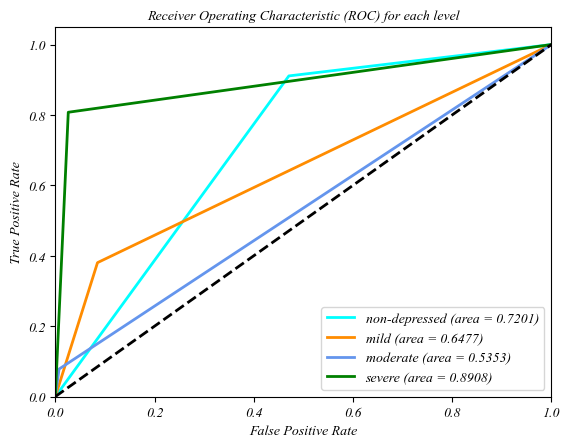

In [12]:
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 加载 Times New Roman 字体
font_path = '/data/zhengtianlong/ttf/timesi.ttf'
times_new_roman_font = fm.FontProperties(fname=font_path)

# 读取JSON文件
input_file_path = '/data/zhengtianlong/Private/Depressed/Close_LLM_Deptweet/ERNIE-4.5-300B-A47B_Depression.json'

with open(input_file_path, 'r', encoding='utf-8') as file:
    data = json.load(file)

# 提取预测值和真实标签
def map_label(predict):
    if "甲" in predict:
        return 0
    elif "乙" in predict:
        return 1
    elif "丙" in predict:
        return 2
    elif "丁" in predict:
        return 3
    else:
        return 3

y_true = [int(item["label"]) for item in data]
y_pred = [map_label(item["predict"]) for item in data]

# 将标签二值化
n_classes = 4
y_true_binarized = label_binarize(y_true, classes=[0, 1, 2, 3])
y_pred_binarized = label_binarize(y_pred, classes=[0, 1, 2, 3])
# 类名映射
class_names = {0: "non-depressed", 1: "mild", 2: "moderate", 3: "severe"}
# 计算ROC曲线和AUC
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_binarized[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 绘制所有类别的ROC曲线
plt.figure()
colors = ['aqua', 'darkorange', 'cornflowerblue', 'green']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             lw=2, label=f'{class_names[i]} (area = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontproperties=times_new_roman_font)
plt.ylabel('True Positive Rate', fontproperties=times_new_roman_font)
plt.title('Receiver Operating Characteristic (ROC) for each level', fontproperties=times_new_roman_font)
plt.legend(loc="lower right", prop=times_new_roman_font)

# 设置刻度字体
plt.xticks(fontproperties=times_new_roman_font)
plt.yticks(fontproperties=times_new_roman_font)

plt.savefig('/data/zhengtianlong/Private/Depressed/result_IMG/ERNIE-4.5-300B-A47B_curves.png', format='png', dpi=800, bbox_inches='tight')
plt.show()


### deepseek-ai/DeepSeek-V3.2

In [ ]:
key = " "

import pandas as pd
import json, os, time
from tqdm import *
from openai import OpenAI

def identify_depression(text):
    client = OpenAI(
        base_url="https://api.siliconflow.cn/v1",
        api_key=key
    )
    prompt = f"""The meanings of tweets at each depression level are as follows：
    - **Non-depressed Tweets**: These tweets express joy, make general statements about depression without personal mental state reflection, or convey casual tiredness, sadness, or temporary hopelessness. They may also express any non-depressive emotion.

    - **Mildly depressed Tweets**: These convey persistent hopelessness or disinterest, with symptoms like guilt, concentration issues, loss of interest, social withdrawal, lack of motivation, weight/appetite changes, daytime sleepiness and fatigue, or reckless behavior (such as, alcohol and drug abuse).

    - **Moderately depressed Tweets**: Similar to mild depression but severe enough to disrupt home/work activities. Symptoms include sensitivity, worthlessness, reduced productivity, low self-esteem, and excessive worry.

    - **Severely depressed Tweets**: These are marked by delusions, insensibility, hallucinations, or suicidal thoughts/behaviors, posing significant life threats.

    Based on the above depression level classification, determine the depression level of the tweet with single-choice options: (甲) Non-depressed, (乙) Mildly depressed, (丙) Moderately depressed, (丁) Severely depressed.

    Tweet: "{text}"

    Please directly output the depression level option 甲, 乙, 丙, or 丁."""

    response = client.chat.completions.create(
        model="deepseek-ai/DeepSeek-V3.2",
        messages=[
            {"role": "user", "content": prompt},
        ],
        max_tokens=2000,
        n=1,
        stop=None,
        temperature=0.5,
    )
    return response.choices[0].message.content

# 确保输出目录存在
output_json_path = "/data/zhengtianlong/Private/Depressed/Close_LLM_Deptweet/DeepSeek-V3.2_Depression.json"
os.makedirs(os.path.dirname(output_json_path), exist_ok=True)

# 如果输出文件已存在，加载已有的ID集合
success_ids = set()
if os.path.exists(output_json_path):
    try:
        with open(output_json_path, "r") as json_file:
            existing_data = json.load(json_file)
            success_ids = {item["Id"] for item in existing_data}
    except json.JSONDecodeError:
        # 文件为空或损坏，重新初始化
        with open(output_json_path, "w") as json_file:
            json.dump([], json_file)
else:
    with open(output_json_path, "w") as json_file:
        json.dump([], json_file)

# 读取数据
data = pd.read_csv('/data/zhengtianlong/Private/Depressed/Deptweet/Deptweet_test.csv')
# 不打乱数据（已移除shuffle）

# 获取所有样本ID（转换为字符串以便比较）
all_ids = set(data['id'].astype(str).tolist())

max_retries = 5
current_retry = 0

# 循环直到所有样本成功或达到最大重试次数
while current_retry < max_retries and len(success_ids) < len(all_ids):
    current_retry += 1
    remaining = len(all_ids) - len(success_ids)
    print(f"重试第 {current_retry}/{max_retries} 轮，剩余 {remaining} 条样本")

    # 本轮需要处理的样本：ID不在 success_ids 中的
    remaining_data = data[~data['id'].astype(str).isin(success_ids)]

    if remaining_data.empty:
        print("所有样本已处理完成")
        break

    # 遍历剩余样本
    for _, row in tqdm(remaining_data.iterrows(), desc=f"第{current_retry}轮", total=len(remaining_data)):
        try:
            Id = str(row['id'])
            text = row['text']
            target = row['target']
            label = row['label']

            if pd.isna(text) or pd.isna(label):
                print(f"跳过缺失文本或标签的样本: {Id}")
                continue

            # 二次检查（理论上不在success_ids中）
            if Id in success_ids:
                continue

            target = str(int(target))  # 保持原处理

            # 调用API
            predict = identify_depression(text)

            result = {"Id": Id, "text": text, "predict": predict, "label": target, "target": label}

            # 写入文件（实时保存）
            with open(output_json_path, "r+") as json_file:
                file_data = json.load(json_file)
                existing_ids = {item["Id"] for item in file_data}
                if Id not in existing_ids:
                    file_data.append(result)
                    json_file.seek(0)
                    json.dump(file_data, json_file, ensure_ascii=False, indent=4)
                    json_file.truncate()  # 清除多余内容
                    success_ids.add(Id)
                else:
                    # 极少情况：文件中有但success_ids没有，则同步
                    print(f"警告: Id {Id} 已存在于文件但不在成功集合中，标记为成功")
                    success_ids.add(Id)

            time.sleep(0.5)  # 保持原延迟

        except Exception as e:
            print(f"处理样本 {Id if 'Id' in locals() else 'unknown'} 时出错: {e}")
            # 失败的不写入，留待下一轮重试
            continue

# ========== 确保最终JSON顺序与原始CSV行顺序一致 ==========
print("正在按原始CSV顺序重新排序输出文件...")
# 构建ID到原始行顺序的映射
id_to_order = {str(row['id']): idx for idx, row in data.iterrows()}

# 读取当前输出文件
with open(output_json_path, "r") as f:
    final_data = json.load(f)

# 按原始顺序排序（缺失的ID放在最后，但理论上不会出现）
final_data.sort(key=lambda x: id_to_order.get(x['Id'], float('inf')))

# 写回文件
with open(output_json_path, "w") as f:
    json.dump(final_data, f, ensure_ascii=False, indent=4)

print("排序完成！")

# 最终结果统计
if len(success_ids) == len(all_ids):
    print("所有样本处理成功！")
else:
    print(f"经过 {max_retries} 轮重试后，仍有 {len(all_ids) - len(success_ids)} 条样本未成功。")

重试第 1/5 轮，剩余 1408 条样本


第1轮: 100%|██████████| 1408/1408 [1:02:47<00:00,  2.68s/it]

正在按原始CSV顺序重新排序输出文件...
排序完成！
所有样本处理成功！


In [2]:
import json, random
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 读取JSON文件
input_file_path = '/data/zhengtianlong/Private/Depressed/Close_LLM_Deptweet/DeepSeek-V3.2_Depression.json'
data = []

with open(input_file_path, 'r', encoding='utf-8') as file:
    data = json.load(file)

# 提取预测值和真实标签
def map_label(predict):
    if "甲" in predict:
        return 0
    elif "乙" in predict:
        return 1
    elif "丙" in predict:
        return 2
    elif "丁" in predict:
        return 3
    else:
        return 3 
        # 为什么要返回3而不是其他 答：模型选择不回答，有可能是因为抑郁症过于严重导致语言过于激烈导致模型无法回答
        # return random.choice([0, 1, 2, 3])

y_true = [int(item["label"]) for item in data]
y_pred = [map_label(item["predict"]) for item in data]

# 计算指标
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')


Accuracy: 69.18%
Precision: 43.57%
Recall: 61.76%
F1 Score: 47.43%


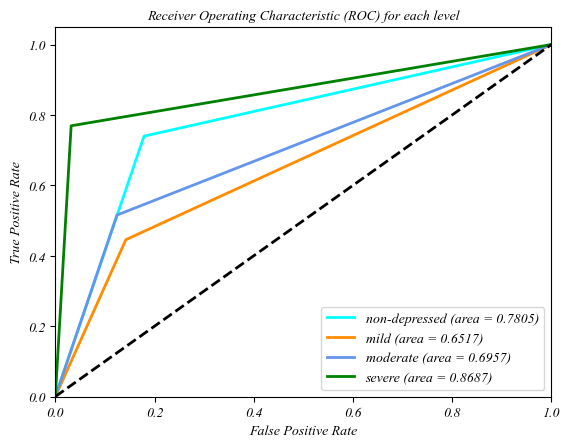

In [3]:
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 加载 Times New Roman 字体
font_path = '/data/zhengtianlong/ttf/timesi.ttf'
times_new_roman_font = fm.FontProperties(fname=font_path)

# 读取JSON文件
input_file_path = '/data/zhengtianlong/Private/Depressed/Close_LLM_Deptweet/DeepSeek-V3.2_Depression.json'

with open(input_file_path, 'r', encoding='utf-8') as file:
    data = json.load(file)

# 提取预测值和真实标签
def map_label(predict):
    if "甲" in predict:
        return 0
    elif "乙" in predict:
        return 1
    elif "丙" in predict:
        return 2
    elif "丁" in predict:
        return 3
    else:
        return 3

y_true = [int(item["label"]) for item in data]
y_pred = [map_label(item["predict"]) for item in data]

# 将标签二值化
n_classes = 4
y_true_binarized = label_binarize(y_true, classes=[0, 1, 2, 3])
y_pred_binarized = label_binarize(y_pred, classes=[0, 1, 2, 3])
# 类名映射
class_names = {0: "non-depressed", 1: "mild", 2: "moderate", 3: "severe"}
# 计算ROC曲线和AUC
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_binarized[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 绘制所有类别的ROC曲线
plt.figure()
colors = ['aqua', 'darkorange', 'cornflowerblue', 'green']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             lw=2, label=f'{class_names[i]} (area = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontproperties=times_new_roman_font)
plt.ylabel('True Positive Rate', fontproperties=times_new_roman_font)
plt.title('Receiver Operating Characteristic (ROC) for each level', fontproperties=times_new_roman_font)
plt.legend(loc="lower right", prop=times_new_roman_font)

# 设置刻度字体
plt.xticks(fontproperties=times_new_roman_font)
plt.yticks(fontproperties=times_new_roman_font)

plt.savefig('/data/zhengtianlong/Private/Depressed/result_IMG/DeepSeek-V3.2_curves.png', format='png', dpi=800, bbox_inches='tight')
plt.show()


### Native Qwen3.5-0.8B-Base

In [1]:
import json
import csv
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# 文件路径
test_csv_path = "/data/zhengtianlong/Private/Depressed/Deptweet/Deptweet_test.csv"
pred_jsonl_path = "/data/zhengtianlong/Private/Depressed/LlamaFactory/saves/Qwen3.5-0.8B-Base/lora/Native_eval_26-03-18-08-43-30/generated_predictions.jsonl"

def map_label(predict_str):
    """根据预测字符串提取标签：按顺序查找 '0','1','2','3'，返回第一个匹配的数字，若均未找到则默认返回3"""
    if "0" in predict_str:
        return 0
    elif "1" in predict_str:
        return 1
    elif "2" in predict_str:
        return 2
    elif "3" in predict_str:
        return 3
    else:
        return 3  # 默认返回3（可调整）

# 1. 读取测试集标签
true_labels = []
with open(test_csv_path, 'r', encoding='utf-8') as f:
    reader = csv.reader(f)
    header = next(reader)  # 跳过表头
    for row in reader:
        if len(row) < 3:
            continue
        target = row[2]  # 第三列是 target
        true_labels.append(int(target))

# 2. 读取预测结果
pred_labels = []
with open(pred_jsonl_path, 'r', encoding='utf-8') as f:
    for line in f:
        data = json.loads(line.strip())
        predict = data.get("predict", "")
        pred_labels.append(map_label(predict))

# 3. 检查数量一致性
if len(true_labels) != len(pred_labels):
    print(f"警告：真实标签数量 {len(true_labels)}，预测标签数量 {len(pred_labels)}，将按较小数量计算。")
    min_len = min(len(true_labels), len(pred_labels))
    true_labels = true_labels[:min_len]
    pred_labels = pred_labels[:min_len]

# 4. 计算四分类指标（使用宏平均 macro）
accuracy = accuracy_score(true_labels, pred_labels)
precision_macro = precision_score(true_labels, pred_labels, average='macro')
recall_macro = recall_score(true_labels, pred_labels, average='macro')
f1_macro = f1_score(true_labels, pred_labels, average='macro')

# 可选：加权平均
precision_weighted = precision_score(true_labels, pred_labels, average='weighted')
recall_weighted = recall_score(true_labels, pred_labels, average='weighted')
f1_weighted = f1_score(true_labels, pred_labels, average='weighted')

# 5. 打印主要结果（宏平均）
print("评估结果（宏平均 Macro）：")
print(f"准确率 (Accuracy): {accuracy*100:.2f}%")
print(f"精确率 (Precision): {precision_macro*100:.2f}%")
print(f"召回率 (Recall): {recall_macro*100:.2f}%")
print(f"F1 值 (F1-score): {f1_macro*100:.2f}%")

# 可选：打印加权平均
print("\n评估结果（加权平均 Weighted）：")
print(f"精确率 (Precision): {precision_weighted*100:.2f}%")
print(f"召回率 (Recall): {recall_weighted*100:.2f}%")
print(f"F1 值 (F1-score): {f1_weighted*100:.2f}%")

# 可选：打印每个类别的详细指标
print("\n各类别详细指标：")
print(classification_report(true_labels, pred_labels, digits=4))

评估结果（宏平均 Macro）：
准确率 (Accuracy): 31.75%
精确率 (Precision): 28.77%
召回率 (Recall): 25.21%
F1 值 (F1-score): 20.66%

评估结果（加权平均 Weighted）：
精确率 (Precision): 73.33%
召回率 (Recall): 31.75%
F1 值 (F1-score): 42.47%

各类别详细指标：
              precision    recall  f1-score   support

           0     0.8784    0.3377    0.4879      1134
           1     0.1616    0.2609    0.1996       184
           2     0.0989    0.1406    0.1161        64
           3     0.0120    0.2692    0.0230        26

    accuracy                         0.3175      1408
   macro avg     0.2877    0.2521    0.2066      1408
weighted avg     0.7333    0.3175    0.4247      1408



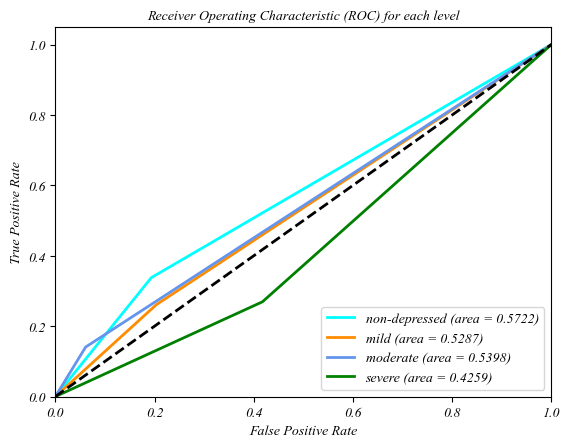

In [2]:
import json, csv
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ================== 配置区域 ==================
# 字体路径（请确保文件存在）
font_path = '/data/zhengtianlong/ttf/timesi.ttf'
# 测试集CSV文件路径
test_csv_path = "/data/zhengtianlong/Private/Depressed/Deptweet/Deptweet_test.csv"
# 预测结果JSONL文件路径
pred_jsonl_path = "/data/zhengtianlong/Private/Depressed/LlamaFactory/saves/Qwen3.5-0.8B-Base/lora/Native_eval_26-03-18-08-43-30/generated_predictions.jsonl"
# 输出图片保存路径
output_img_path = "/data/zhengtianlong/Private/Depressed/result_IMG/Native_Qwen3.5-0.8B-Base_ROC_curves.png"
# =============================================

# 加载字体
times_new_roman_font = fm.FontProperties(fname=font_path)

def map_label(predict_str):
    """
    从预测字符串中提取类别标签（0-3）。
    假设模型输出中可能包含数字 '0','1','2','3'，按顺序匹配第一个数字。
    若未匹配到任何数字，默认返回3（可根据实际情况调整）。
    """
    if "0" in predict_str:
        return 0
    elif "1" in predict_str:
        return 1
    elif "2" in predict_str:
        return 2
    elif "3" in predict_str:
        return 3
    else:
        return 3  # 默认类别

# 1. 读取测试集真实标签
true_labels = []
with open(test_csv_path, 'r', encoding='utf-8') as f:
    reader = csv.reader(f)
    header = next(reader)  # 跳过表头
    for row in reader:
        if len(row) < 3:
            continue
        target = row[2]  # 第三列是 target（0/1/2/3）
        true_labels.append(int(target))

# 2. 读取预测结果
pred_labels = []
with open(pred_jsonl_path, 'r', encoding='utf-8') as f:
    for line in f:
        data = json.loads(line.strip())
        predict = data.get("predict", "")
        pred_labels.append(map_label(predict))

# 3. 检查数量一致性并截断
if len(true_labels) != len(pred_labels):
    print(f"警告：真实标签数量 {len(true_labels)}，预测标签数量 {len(pred_labels)}，将按较小数量计算。")
    min_len = min(len(true_labels), len(pred_labels))
    true_labels = true_labels[:min_len]
    pred_labels = pred_labels[:min_len]

# 4. 构建与画图代码兼容的数据格式（列表 of dict）
data = [{"label": t, "predict": p} for t, p in zip(true_labels, pred_labels)]

# 5. 准备ROC曲线所需数据
y_true = [int(item["label"]) for item in data]
y_pred = [int(item["predict"]) for item in data]  # 此处predict已是整数

# 将标签二值化
n_classes = 4
y_true_binarized = label_binarize(y_true, classes=[0, 1, 2, 3])
y_pred_binarized = label_binarize(y_pred, classes=[0, 1, 2, 3])

# 类别名称映射（可根据实际修改）
class_names = {0: "non-depressed", 1: "mild", 2: "moderate", 3: "severe"}

# 计算ROC曲线和AUC
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_binarized[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 绘制所有类别的ROC曲线
plt.figure()
colors = ['aqua', 'darkorange', 'cornflowerblue', 'green']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             lw=2, label=f'{class_names[i]} (area = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontproperties=times_new_roman_font)
plt.ylabel('True Positive Rate', fontproperties=times_new_roman_font)
plt.title('Receiver Operating Characteristic (ROC) for each level', fontproperties=times_new_roman_font)
plt.legend(loc="lower right", prop=times_new_roman_font)

# 设置刻度字体
plt.xticks(fontproperties=times_new_roman_font)
plt.yticks(fontproperties=times_new_roman_font)

plt.savefig(output_img_path, format='png', dpi=800, bbox_inches='tight')
plt.show()

### Native Qwen3.5-2B-Base

In [3]:
import json
import csv
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# 文件路径
test_csv_path = "/data/zhengtianlong/Private/Depressed/Deptweet/Deptweet_test.csv"
pred_jsonl_path = "/data/zhengtianlong/Private/Depressed/LlamaFactory/saves/Qwen3.5-2B-Base/lora/Native_eval_26-03-18-08-43-30/generated_predictions.jsonl"

def map_label(predict_str):
    """根据预测字符串提取标签：按顺序查找 '0','1','2','3'，返回第一个匹配的数字，若均未找到则默认返回3"""
    if "0" in predict_str:
        return 0
    elif "1" in predict_str:
        return 1
    elif "2" in predict_str:
        return 2
    elif "3" in predict_str:
        return 3
    else:
        return 3  # 默认返回3（可调整）

# 1. 读取测试集标签
true_labels = []
with open(test_csv_path, 'r', encoding='utf-8') as f:
    reader = csv.reader(f)
    header = next(reader)  # 跳过表头
    for row in reader:
        if len(row) < 3:
            continue
        target = row[2]  # 第三列是 target
        true_labels.append(int(target))

# 2. 读取预测结果
pred_labels = []
with open(pred_jsonl_path, 'r', encoding='utf-8') as f:
    for line in f:
        data = json.loads(line.strip())
        predict = data.get("predict", "")
        pred_labels.append(map_label(predict))

# 3. 检查数量一致性
if len(true_labels) != len(pred_labels):
    print(f"警告：真实标签数量 {len(true_labels)}，预测标签数量 {len(pred_labels)}，将按较小数量计算。")
    min_len = min(len(true_labels), len(pred_labels))
    true_labels = true_labels[:min_len]
    pred_labels = pred_labels[:min_len]

# 4. 计算四分类指标（使用宏平均 macro）
accuracy = accuracy_score(true_labels, pred_labels)
precision_macro = precision_score(true_labels, pred_labels, average='macro')
recall_macro = recall_score(true_labels, pred_labels, average='macro')
f1_macro = f1_score(true_labels, pred_labels, average='macro')

# 可选：加权平均
precision_weighted = precision_score(true_labels, pred_labels, average='weighted')
recall_weighted = recall_score(true_labels, pred_labels, average='weighted')
f1_weighted = f1_score(true_labels, pred_labels, average='weighted')

# 5. 打印主要结果（宏平均）
print("评估结果（宏平均 Macro）：")
print(f"准确率 (Accuracy): {accuracy*100:.2f}%")
print(f"精确率 (Precision): {precision_macro*100:.2f}%")
print(f"召回率 (Recall): {recall_macro*100:.2f}%")
print(f"F1 值 (F1-score): {f1_macro*100:.2f}%")

# 可选：打印加权平均
print("\n评估结果（加权平均 Weighted）：")
print(f"精确率 (Precision): {precision_weighted*100:.2f}%")
print(f"召回率 (Recall): {recall_weighted*100:.2f}%")
print(f"F1 值 (F1-score): {f1_weighted*100:.2f}%")

# 可选：打印每个类别的详细指标
print("\n各类别详细指标：")
print(classification_report(true_labels, pred_labels, digits=4))

评估结果（宏平均 Macro）：
准确率 (Accuracy): 42.19%
精确率 (Precision): 32.42%
召回率 (Recall): 37.30%
F1 值 (F1-score): 27.56%

评估结果（加权平均 Weighted）：
精确率 (Precision): 75.02%
召回率 (Recall): 42.19%
F1 值 (F1-score): 51.94%

各类别详细指标：
              precision    recall  f1-score   support

           0     0.8885    0.4427    0.5909      1134
           1     0.1976    0.3533    0.2534       184
           2     0.1829    0.2344    0.2055        64
           3     0.0278    0.4615    0.0524        26

    accuracy                         0.4219      1408
   macro avg     0.3242    0.3730    0.2756      1408
weighted avg     0.7502    0.4219    0.5194      1408



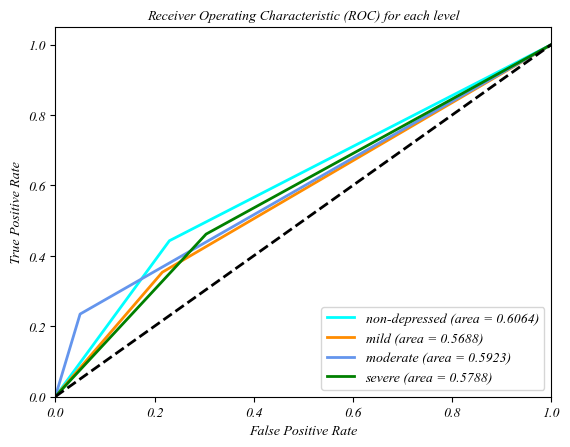

In [4]:
import json, csv
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ================== 配置区域 ==================
# 字体路径（请确保文件存在）
font_path = '/data/zhengtianlong/ttf/timesi.ttf'
# 测试集CSV文件路径
test_csv_path = "/data/zhengtianlong/Private/Depressed/Deptweet/Deptweet_test.csv"
# 预测结果JSONL文件路径
pred_jsonl_path = "/data/zhengtianlong/Private/Depressed/LlamaFactory/saves/Qwen3.5-2B-Base/lora/Native_eval_26-03-18-08-43-30/generated_predictions.jsonl"
# 输出图片保存路径
output_img_path = "/data/zhengtianlong/Private/Depressed/result_IMG/Native_Qwen3.5-2B-Base_ROC_curves.png"
# =============================================

# 加载字体
times_new_roman_font = fm.FontProperties(fname=font_path)

def map_label(predict_str):
    """
    从预测字符串中提取类别标签（0-3）。
    假设模型输出中可能包含数字 '0','1','2','3'，按顺序匹配第一个数字。
    若未匹配到任何数字，默认返回3（可根据实际情况调整）。
    """
    if "0" in predict_str:
        return 0
    elif "1" in predict_str:
        return 1
    elif "2" in predict_str:
        return 2
    elif "3" in predict_str:
        return 3
    else:
        return 3  # 默认类别

# 1. 读取测试集真实标签
true_labels = []
with open(test_csv_path, 'r', encoding='utf-8') as f:
    reader = csv.reader(f)
    header = next(reader)  # 跳过表头
    for row in reader:
        if len(row) < 3:
            continue
        target = row[2]  # 第三列是 target（0/1/2/3）
        true_labels.append(int(target))

# 2. 读取预测结果
pred_labels = []
with open(pred_jsonl_path, 'r', encoding='utf-8') as f:
    for line in f:
        data = json.loads(line.strip())
        predict = data.get("predict", "")
        pred_labels.append(map_label(predict))

# 3. 检查数量一致性并截断
if len(true_labels) != len(pred_labels):
    print(f"警告：真实标签数量 {len(true_labels)}，预测标签数量 {len(pred_labels)}，将按较小数量计算。")
    min_len = min(len(true_labels), len(pred_labels))
    true_labels = true_labels[:min_len]
    pred_labels = pred_labels[:min_len]

# 4. 构建与画图代码兼容的数据格式（列表 of dict）
data = [{"label": t, "predict": p} for t, p in zip(true_labels, pred_labels)]

# 5. 准备ROC曲线所需数据
y_true = [int(item["label"]) for item in data]
y_pred = [int(item["predict"]) for item in data]  # 此处predict已是整数

# 将标签二值化
n_classes = 4
y_true_binarized = label_binarize(y_true, classes=[0, 1, 2, 3])
y_pred_binarized = label_binarize(y_pred, classes=[0, 1, 2, 3])

# 类别名称映射（可根据实际修改）
class_names = {0: "non-depressed", 1: "mild", 2: "moderate", 3: "severe"}

# 计算ROC曲线和AUC
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_binarized[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 绘制所有类别的ROC曲线
plt.figure()
colors = ['aqua', 'darkorange', 'cornflowerblue', 'green']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             lw=2, label=f'{class_names[i]} (area = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontproperties=times_new_roman_font)
plt.ylabel('True Positive Rate', fontproperties=times_new_roman_font)
plt.title('Receiver Operating Characteristic (ROC) for each level', fontproperties=times_new_roman_font)
plt.legend(loc="lower right", prop=times_new_roman_font)

# 设置刻度字体
plt.xticks(fontproperties=times_new_roman_font)
plt.yticks(fontproperties=times_new_roman_font)

plt.savefig(output_img_path, format='png', dpi=800, bbox_inches='tight')
plt.show()

### Native Qwen3.5-4B-Base

In [5]:
import json
import csv
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# 文件路径
test_csv_path = "/data/zhengtianlong/Private/Depressed/Deptweet/Deptweet_test.csv"
pred_jsonl_path = "/data/zhengtianlong/Private/Depressed/LlamaFactory/saves/Qwen3.5-4B-Base/lora/Native_eval_26-03-18-08-43-30/generated_predictions.jsonl"

def map_label(predict_str):
    """根据预测字符串提取标签：按顺序查找 '0','1','2','3'，返回第一个匹配的数字，若均未找到则默认返回3"""
    if "0" in predict_str:
        return 0
    elif "1" in predict_str:
        return 1
    elif "2" in predict_str:
        return 2
    elif "3" in predict_str:
        return 3
    else:
        return 3  # 默认返回3（可调整）

# 1. 读取测试集标签
true_labels = []
with open(test_csv_path, 'r', encoding='utf-8') as f:
    reader = csv.reader(f)
    header = next(reader)  # 跳过表头
    for row in reader:
        if len(row) < 3:
            continue
        target = row[2]  # 第三列是 target
        true_labels.append(int(target))

# 2. 读取预测结果
pred_labels = []
with open(pred_jsonl_path, 'r', encoding='utf-8') as f:
    for line in f:
        data = json.loads(line.strip())
        predict = data.get("predict", "")
        pred_labels.append(map_label(predict))

# 3. 检查数量一致性
if len(true_labels) != len(pred_labels):
    print(f"警告：真实标签数量 {len(true_labels)}，预测标签数量 {len(pred_labels)}，将按较小数量计算。")
    min_len = min(len(true_labels), len(pred_labels))
    true_labels = true_labels[:min_len]
    pred_labels = pred_labels[:min_len]

# 4. 计算四分类指标（使用宏平均 macro）
accuracy = accuracy_score(true_labels, pred_labels)
precision_macro = precision_score(true_labels, pred_labels, average='macro')
recall_macro = recall_score(true_labels, pred_labels, average='macro')
f1_macro = f1_score(true_labels, pred_labels, average='macro')

# 可选：加权平均
precision_weighted = precision_score(true_labels, pred_labels, average='weighted')
recall_weighted = recall_score(true_labels, pred_labels, average='weighted')
f1_weighted = f1_score(true_labels, pred_labels, average='weighted')

# 5. 打印主要结果（宏平均）
print("评估结果（宏平均 Macro）：")
print(f"准确率 (Accuracy): {accuracy*100:.2f}%")
print(f"精确率 (Precision): {precision_macro*100:.2f}%")
print(f"召回率 (Recall): {recall_macro*100:.2f}%")
print(f"F1 值 (F1-score): {f1_macro*100:.2f}%")

# 可选：打印加权平均
print("\n评估结果（加权平均 Weighted）：")
print(f"精确率 (Precision): {precision_weighted*100:.2f}%")
print(f"召回率 (Recall): {recall_weighted*100:.2f}%")
print(f"F1 值 (F1-score): {f1_weighted*100:.2f}%")

# 可选：打印每个类别的详细指标
print("\n各类别详细指标：")
print(classification_report(true_labels, pred_labels, digits=4))

评估结果（宏平均 Macro）：
准确率 (Accuracy): 59.16%
精确率 (Precision): 35.79%
召回率 (Recall): 40.46%
F1 值 (F1-score): 33.16%

评估结果（加权平均 Weighted）：
精确率 (Precision): 75.93%
召回率 (Recall): 59.16%
F1 值 (F1-score): 65.84%

各类别详细指标：
              precision    recall  f1-score   support

           0     0.8903    0.6658    0.7619      1134
           1     0.2208    0.2880    0.2500       184
           2     0.2766    0.2031    0.2342        64
           3     0.0440    0.4615    0.0803        26

    accuracy                         0.5916      1408
   macro avg     0.3579    0.4046    0.3316      1408
weighted avg     0.7593    0.5916    0.6584      1408



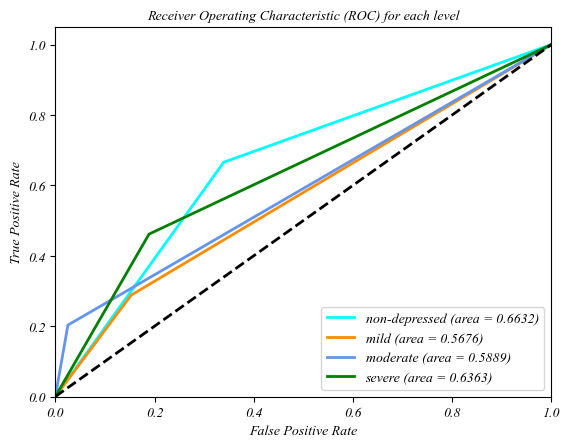

In [6]:
import json, csv
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ================== 配置区域 ==================
# 字体路径（请确保文件存在）
font_path = '/data/zhengtianlong/ttf/timesi.ttf'
# 测试集CSV文件路径
test_csv_path = "/data/zhengtianlong/Private/Depressed/Deptweet/Deptweet_test.csv"
# 预测结果JSONL文件路径
pred_jsonl_path = "/data/zhengtianlong/Private/Depressed/LlamaFactory/saves/Qwen3.5-4B-Base/lora/Native_eval_26-03-18-08-43-30/generated_predictions.jsonl"
# 输出图片保存路径
output_img_path = "/data/zhengtianlong/Private/Depressed/result_IMG/Native_Qwen3.5-4B-Base_ROC_curves.png"
# =============================================

# 加载字体
times_new_roman_font = fm.FontProperties(fname=font_path)

def map_label(predict_str):
    """
    从预测字符串中提取类别标签（0-3）。
    假设模型输出中可能包含数字 '0','1','2','3'，按顺序匹配第一个数字。
    若未匹配到任何数字，默认返回3（可根据实际情况调整）。
    """
    if "0" in predict_str:
        return 0
    elif "1" in predict_str:
        return 1
    elif "2" in predict_str:
        return 2
    elif "3" in predict_str:
        return 3
    else:
        return 3  # 默认类别

# 1. 读取测试集真实标签
true_labels = []
with open(test_csv_path, 'r', encoding='utf-8') as f:
    reader = csv.reader(f)
    header = next(reader)  # 跳过表头
    for row in reader:
        if len(row) < 3:
            continue
        target = row[2]  # 第三列是 target（0/1/2/3）
        true_labels.append(int(target))

# 2. 读取预测结果
pred_labels = []
with open(pred_jsonl_path, 'r', encoding='utf-8') as f:
    for line in f:
        data = json.loads(line.strip())
        predict = data.get("predict", "")
        pred_labels.append(map_label(predict))

# 3. 检查数量一致性并截断
if len(true_labels) != len(pred_labels):
    print(f"警告：真实标签数量 {len(true_labels)}，预测标签数量 {len(pred_labels)}，将按较小数量计算。")
    min_len = min(len(true_labels), len(pred_labels))
    true_labels = true_labels[:min_len]
    pred_labels = pred_labels[:min_len]

# 4. 构建与画图代码兼容的数据格式（列表 of dict）
data = [{"label": t, "predict": p} for t, p in zip(true_labels, pred_labels)]

# 5. 准备ROC曲线所需数据
y_true = [int(item["label"]) for item in data]
y_pred = [int(item["predict"]) for item in data]  # 此处predict已是整数

# 将标签二值化
n_classes = 4
y_true_binarized = label_binarize(y_true, classes=[0, 1, 2, 3])
y_pred_binarized = label_binarize(y_pred, classes=[0, 1, 2, 3])

# 类别名称映射（可根据实际修改）
class_names = {0: "non-depressed", 1: "mild", 2: "moderate", 3: "severe"}

# 计算ROC曲线和AUC
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_binarized[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 绘制所有类别的ROC曲线
plt.figure()
colors = ['aqua', 'darkorange', 'cornflowerblue', 'green']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             lw=2, label=f'{class_names[i]} (area = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontproperties=times_new_roman_font)
plt.ylabel('True Positive Rate', fontproperties=times_new_roman_font)
plt.title('Receiver Operating Characteristic (ROC) for each level', fontproperties=times_new_roman_font)
plt.legend(loc="lower right", prop=times_new_roman_font)

# 设置刻度字体
plt.xticks(fontproperties=times_new_roman_font)
plt.yticks(fontproperties=times_new_roman_font)

plt.savefig(output_img_path, format='png', dpi=800, bbox_inches='tight')
plt.show()

### Native Qwen3.5-9B-Base

In [7]:
import json
import csv
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# 文件路径
test_csv_path = "/data/zhengtianlong/Private/Depressed/Deptweet/Deptweet_test.csv"
pred_jsonl_path = "/data/zhengtianlong/Private/Depressed/LlamaFactory/saves/Qwen3.5-9B-Base/lora/Native_eval_26-03-18-08-43-30/generated_predictions.jsonl"

def map_label(predict_str):
    """根据预测字符串提取标签：按顺序查找 '0','1','2','3'，返回第一个匹配的数字，若均未找到则默认返回3"""
    if "0" in predict_str:
        return 0
    elif "1" in predict_str:
        return 1
    elif "2" in predict_str:
        return 2
    elif "3" in predict_str:
        return 3
    else:
        return 3  # 默认返回3（可调整）

# 1. 读取测试集标签
true_labels = []
with open(test_csv_path, 'r', encoding='utf-8') as f:
    reader = csv.reader(f)
    header = next(reader)  # 跳过表头
    for row in reader:
        if len(row) < 3:
            continue
        target = row[2]  # 第三列是 target
        true_labels.append(int(target))

# 2. 读取预测结果
pred_labels = []
with open(pred_jsonl_path, 'r', encoding='utf-8') as f:
    for line in f:
        data = json.loads(line.strip())
        predict = data.get("predict", "")
        pred_labels.append(map_label(predict))

# 3. 检查数量一致性
if len(true_labels) != len(pred_labels):
    print(f"警告：真实标签数量 {len(true_labels)}，预测标签数量 {len(pred_labels)}，将按较小数量计算。")
    min_len = min(len(true_labels), len(pred_labels))
    true_labels = true_labels[:min_len]
    pred_labels = pred_labels[:min_len]

# 4. 计算四分类指标（使用宏平均 macro）
accuracy = accuracy_score(true_labels, pred_labels)
precision_macro = precision_score(true_labels, pred_labels, average='macro')
recall_macro = recall_score(true_labels, pred_labels, average='macro')
f1_macro = f1_score(true_labels, pred_labels, average='macro')

# 可选：加权平均
precision_weighted = precision_score(true_labels, pred_labels, average='weighted')
recall_weighted = recall_score(true_labels, pred_labels, average='weighted')
f1_weighted = f1_score(true_labels, pred_labels, average='weighted')

# 5. 打印主要结果（宏平均）
print("评估结果（宏平均 Macro）：")
print(f"准确率 (Accuracy): {accuracy*100:.2f}%")
print(f"精确率 (Precision): {precision_macro*100:.2f}%")
print(f"召回率 (Recall): {recall_macro*100:.2f}%")
print(f"F1 值 (F1-score): {f1_macro*100:.2f}%")

# 可选：打印加权平均
print("\n评估结果（加权平均 Weighted）：")
print(f"精确率 (Precision): {precision_weighted*100:.2f}%")
print(f"召回率 (Recall): {recall_weighted*100:.2f}%")
print(f"F1 值 (F1-score): {f1_weighted*100:.2f}%")

# 可选：打印每个类别的详细指标
print("\n各类别详细指标：")
print(classification_report(true_labels, pred_labels, digits=4))

评估结果（宏平均 Macro）：
准确率 (Accuracy): 62.43%
精确率 (Precision): 37.94%
召回率 (Recall): 46.59%
F1 值 (F1-score): 36.99%

评估结果（加权平均 Weighted）：
精确率 (Precision): 77.40%
召回率 (Recall): 62.43%
F1 值 (F1-score): 68.42%

各类别详细指标：
              precision    recall  f1-score   support

           0     0.8991    0.6914    0.7817      1134
           1     0.2731    0.3370    0.3017       184
           2     0.2879    0.2969    0.2923        64
           3     0.0576    0.5385    0.1041        26

    accuracy                         0.6243      1408
   macro avg     0.3794    0.4659    0.3699      1408
weighted avg     0.7740    0.6243    0.6842      1408



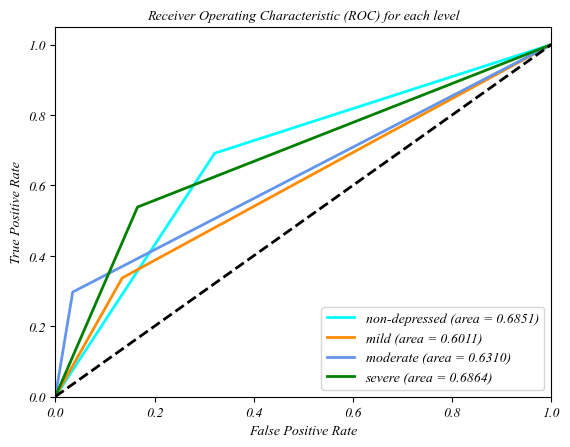

In [8]:
import json, csv
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ================== 配置区域 ==================
# 字体路径（请确保文件存在）
font_path = '/data/zhengtianlong/ttf/timesi.ttf'
# 测试集CSV文件路径
test_csv_path = "/data/zhengtianlong/Private/Depressed/Deptweet/Deptweet_test.csv"
# 预测结果JSONL文件路径
pred_jsonl_path = "/data/zhengtianlong/Private/Depressed/LlamaFactory/saves/Qwen3.5-9B-Base/lora/Native_eval_26-03-18-08-43-30/generated_predictions.jsonl"
# 输出图片保存路径
output_img_path = "/data/zhengtianlong/Private/Depressed/result_IMG/Native_Qwen3.5-9B-Base_ROC_curves.png"
# =============================================

# 加载字体
times_new_roman_font = fm.FontProperties(fname=font_path)

def map_label(predict_str):
    """
    从预测字符串中提取类别标签（0-3）。
    假设模型输出中可能包含数字 '0','1','2','3'，按顺序匹配第一个数字。
    若未匹配到任何数字，默认返回3（可根据实际情况调整）。
    """
    if "0" in predict_str:
        return 0
    elif "1" in predict_str:
        return 1
    elif "2" in predict_str:
        return 2
    elif "3" in predict_str:
        return 3
    else:
        return 3  # 默认类别

# 1. 读取测试集真实标签
true_labels = []
with open(test_csv_path, 'r', encoding='utf-8') as f:
    reader = csv.reader(f)
    header = next(reader)  # 跳过表头
    for row in reader:
        if len(row) < 3:
            continue
        target = row[2]  # 第三列是 target（0/1/2/3）
        true_labels.append(int(target))

# 2. 读取预测结果
pred_labels = []
with open(pred_jsonl_path, 'r', encoding='utf-8') as f:
    for line in f:
        data = json.loads(line.strip())
        predict = data.get("predict", "")
        pred_labels.append(map_label(predict))

# 3. 检查数量一致性并截断
if len(true_labels) != len(pred_labels):
    print(f"警告：真实标签数量 {len(true_labels)}，预测标签数量 {len(pred_labels)}，将按较小数量计算。")
    min_len = min(len(true_labels), len(pred_labels))
    true_labels = true_labels[:min_len]
    pred_labels = pred_labels[:min_len]

# 4. 构建与画图代码兼容的数据格式（列表 of dict）
data = [{"label": t, "predict": p} for t, p in zip(true_labels, pred_labels)]

# 5. 准备ROC曲线所需数据
y_true = [int(item["label"]) for item in data]
y_pred = [int(item["predict"]) for item in data]  # 此处predict已是整数

# 将标签二值化
n_classes = 4
y_true_binarized = label_binarize(y_true, classes=[0, 1, 2, 3])
y_pred_binarized = label_binarize(y_pred, classes=[0, 1, 2, 3])

# 类别名称映射（可根据实际修改）
class_names = {0: "non-depressed", 1: "mild", 2: "moderate", 3: "severe"}

# 计算ROC曲线和AUC
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_binarized[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 绘制所有类别的ROC曲线
plt.figure()
colors = ['aqua', 'darkorange', 'cornflowerblue', 'green']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             lw=2, label=f'{class_names[i]} (area = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontproperties=times_new_roman_font)
plt.ylabel('True Positive Rate', fontproperties=times_new_roman_font)
plt.title('Receiver Operating Characteristic (ROC) for each level', fontproperties=times_new_roman_font)
plt.legend(loc="lower right", prop=times_new_roman_font)

# 设置刻度字体
plt.xticks(fontproperties=times_new_roman_font)
plt.yticks(fontproperties=times_new_roman_font)

plt.savefig(output_img_path, format='png', dpi=800, bbox_inches='tight')
plt.show()

### Native Qwen3.5-35B-A3B-Base

In [1]:
import json
import csv
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# 文件路径
test_csv_path = "/data/zhengtianlong/Private/Depressed/Deptweet/Deptweet_test.csv"
pred_jsonl_path = "/data/zhengtianlong/Private/Depressed/LlamaFactory/saves/Qwen3.5-35B-A3B-Base/lora/Native_eval_26-03-18-08-43-30/generated_predictions.jsonl"

def map_label(predict_str):
    """根据预测字符串提取标签：按顺序查找 '0','1','2','3'，返回第一个匹配的数字，若均未找到则默认返回3"""
    if "0" in predict_str:
        return 0
    elif "1" in predict_str:
        return 1
    elif "2" in predict_str:
        return 2
    elif "3" in predict_str:
        return 3
    else:
        return 3  # 默认返回3（可调整）

# 1. 读取测试集标签
true_labels = []
with open(test_csv_path, 'r', encoding='utf-8') as f:
    reader = csv.reader(f)
    header = next(reader)  # 跳过表头
    for row in reader:
        if len(row) < 3:
            continue
        target = row[2]  # 第三列是 target
        true_labels.append(int(target))

# 2. 读取预测结果
pred_labels = []
with open(pred_jsonl_path, 'r', encoding='utf-8') as f:
    for line in f:
        data = json.loads(line.strip())
        predict = data.get("predict", "")
        pred_labels.append(map_label(predict))

# 3. 检查数量一致性
if len(true_labels) != len(pred_labels):
    print(f"警告：真实标签数量 {len(true_labels)}，预测标签数量 {len(pred_labels)}，将按较小数量计算。")
    min_len = min(len(true_labels), len(pred_labels))
    true_labels = true_labels[:min_len]
    pred_labels = pred_labels[:min_len]

# 4. 计算四分类指标（使用宏平均 macro）
accuracy = accuracy_score(true_labels, pred_labels)
precision_macro = precision_score(true_labels, pred_labels, average='macro')
recall_macro = recall_score(true_labels, pred_labels, average='macro')
f1_macro = f1_score(true_labels, pred_labels, average='macro')

# 可选：加权平均
precision_weighted = precision_score(true_labels, pred_labels, average='weighted')
recall_weighted = recall_score(true_labels, pred_labels, average='weighted')
f1_weighted = f1_score(true_labels, pred_labels, average='weighted')

# 5. 打印主要结果（宏平均）
print("评估结果（宏平均 Macro）：")
print(f"准确率 (Accuracy): {accuracy*100:.2f}%")
print(f"精确率 (Precision): {precision_macro*100:.2f}%")
print(f"召回率 (Recall): {recall_macro*100:.2f}%")
print(f"F1 值 (F1-score): {f1_macro*100:.2f}%")

# 可选：打印加权平均
print("\n评估结果（加权平均 Weighted）：")
print(f"精确率 (Precision): {precision_weighted*100:.2f}%")
print(f"召回率 (Recall): {recall_weighted*100:.2f}%")
print(f"F1 值 (F1-score): {f1_weighted*100:.2f}%")

# 可选：打印每个类别的详细指标
print("\n各类别详细指标：")
print(classification_report(true_labels, pred_labels, digits=4))

评估结果（宏平均 Macro）：
准确率 (Accuracy): 63.85%
精确率 (Precision): 35.53%
召回率 (Recall): 49.43%
F1 值 (F1-score): 35.66%

评估结果（加权平均 Weighted）：
精确率 (Precision): 77.76%
召回率 (Recall): 63.85%
F1 值 (F1-score): 69.32%

各类别详细指标：
              precision    recall  f1-score   support

           0     0.9099    0.7125    0.7992      1134
           1     0.2802    0.3152    0.2967       184
           2     0.1429    0.2188    0.1728        64
           3     0.0884    0.7308    0.1577        26

    accuracy                         0.6385      1408
   macro avg     0.3553    0.4943    0.3566      1408
weighted avg     0.7776    0.6385    0.6932      1408



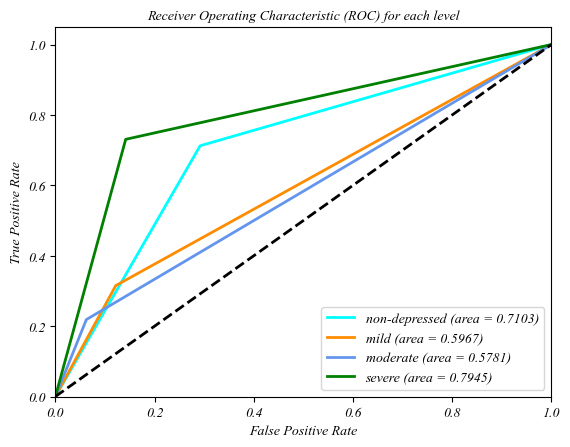

In [2]:
import json, csv
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ================== 配置区域 ==================
# 字体路径（请确保文件存在）
font_path = '/data/zhengtianlong/ttf/timesi.ttf'
# 测试集CSV文件路径
test_csv_path = "/data/zhengtianlong/Private/Depressed/Deptweet/Deptweet_test.csv"
# 预测结果JSONL文件路径
pred_jsonl_path = "/data/zhengtianlong/Private/Depressed/LlamaFactory/saves/Qwen3.5-35B-A3B-Base/lora/Native_eval_26-03-18-08-43-30/generated_predictions.jsonl"
# 输出图片保存路径
output_img_path = "/data/zhengtianlong/Private/Depressed/result_IMG/Native_Qwen3.5-35B-A3B-Base_ROC_curves.png"
# =============================================

# 加载字体
times_new_roman_font = fm.FontProperties(fname=font_path)

def map_label(predict_str):
    """
    从预测字符串中提取类别标签（0-3）。
    假设模型输出中可能包含数字 '0','1','2','3'，按顺序匹配第一个数字。
    若未匹配到任何数字，默认返回3（可根据实际情况调整）。
    """
    if "0" in predict_str:
        return 0
    elif "1" in predict_str:
        return 1
    elif "2" in predict_str:
        return 2
    elif "3" in predict_str:
        return 3
    else:
        return 3  # 默认类别

# 1. 读取测试集真实标签
true_labels = []
with open(test_csv_path, 'r', encoding='utf-8') as f:
    reader = csv.reader(f)
    header = next(reader)  # 跳过表头
    for row in reader:
        if len(row) < 3:
            continue
        target = row[2]  # 第三列是 target（0/1/2/3）
        true_labels.append(int(target))

# 2. 读取预测结果
pred_labels = []
with open(pred_jsonl_path, 'r', encoding='utf-8') as f:
    for line in f:
        data = json.loads(line.strip())
        predict = data.get("predict", "")
        pred_labels.append(map_label(predict))

# 3. 检查数量一致性并截断
if len(true_labels) != len(pred_labels):
    print(f"警告：真实标签数量 {len(true_labels)}，预测标签数量 {len(pred_labels)}，将按较小数量计算。")
    min_len = min(len(true_labels), len(pred_labels))
    true_labels = true_labels[:min_len]
    pred_labels = pred_labels[:min_len]

# 4. 构建与画图代码兼容的数据格式（列表 of dict）
data = [{"label": t, "predict": p} for t, p in zip(true_labels, pred_labels)]

# 5. 准备ROC曲线所需数据
y_true = [int(item["label"]) for item in data]
y_pred = [int(item["predict"]) for item in data]  # 此处predict已是整数

# 将标签二值化
n_classes = 4
y_true_binarized = label_binarize(y_true, classes=[0, 1, 2, 3])
y_pred_binarized = label_binarize(y_pred, classes=[0, 1, 2, 3])

# 类别名称映射（可根据实际修改）
class_names = {0: "non-depressed", 1: "mild", 2: "moderate", 3: "severe"}

# 计算ROC曲线和AUC
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_pred_binarized[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 绘制所有类别的ROC曲线
plt.figure()
colors = ['aqua', 'darkorange', 'cornflowerblue', 'green']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color,
             lw=2, label=f'{class_names[i]} (area = {roc_auc[i]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontproperties=times_new_roman_font)
plt.ylabel('True Positive Rate', fontproperties=times_new_roman_font)
plt.title('Receiver Operating Characteristic (ROC) for each level', fontproperties=times_new_roman_font)
plt.legend(loc="lower right", prop=times_new_roman_font)

# 设置刻度字体
plt.xticks(fontproperties=times_new_roman_font)
plt.yticks(fontproperties=times_new_roman_font)

plt.savefig(output_img_path, format='png', dpi=800, bbox_inches='tight')
plt.show()